In [ ]:
# Makes sure that the notebook is reloaded when changes are made to other files in the project
%load_ext autoreload
%autoreload 2

import sys

# check if i am running in the same python environment as vscode
terminal_venv = '/Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/venv/bin/python'
if sys.executable == terminal_venv:
    print(f"Running in the same python environment as vscode\n{sys.executable}")
else:
    print(f"Running in a different python environment than vscode\n{sys.executable}")

In [ ]:
import anywidget
import plotly.io as pio
pio.renderers.default = 'notebook'


import torch
import matplotlib.pyplot as plt

from core.context import cfg
from core.solver import PINNSolver

from utils.visualizer import create_pinn_video
from utils.visualizer import create_interactive_3d_concentration

# set the experiment seed
exp_seed = 42
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'\nStarting experiment on device {device}')

# instantiate the solver
solver = PINNSolver(physics_configuration=cfg, neurons=16, layers=5, n_pde=2000, device=device, seed=exp_seed)
# print(solver)

# plot dataset
solver.pde_training_dataset.plotme()

# training pipeline
# train simple adam for some epochs
solver.train_adam(method='vanilla', epochs=5000)

# # fine tune with dynamic weight algorithm
# solver.train_adam(method='dynweight', epochs=15000, update_weights_every=20, wait_until=5000)

# # further fine-tune with adaptive resampling
# solver.train_adam(epochs=30000, problem_type='forward', method='adaptive_resampling', accumulate=False, rard_sample_size=500, resample_every=500, wait_until=5000)
# # plot residual maps
# # plot new dataset

# # train for some epochs with simple adam
# solver.train_adam(method='vanilla', epochs=5000)

# # final fine tuning with lbfgs algorithm - freeze dynamic weight here.
# solver.train_lbfgs(epochs=300, problem_type='forward')

# vizualization of the 2d concentrations
solver.vizualize_prediction('cf', [0, 6, 12, 18, 24])

create_pinn_video(image_folder=solver.static_3D_dir, video_folder='antibody_penetration_3D.mp4', fps=5)
create_interactive_3d_concentration(n_r=20, n_t=100, model=solver.approximator)
# # vizualization of losses



In [ ]:
import pandas as pd
def data_to_df(data):
    d = {k: [v.item()] for k, v in data.items()}
    return pd.DataFrame(data=d)

import plotly.io as pio
pio.renderers.default = 'notebook'
import pandas as pd

from core.solver import PINNSolver
from utils.visualizer import create_interactive_3d_concentration, create_norm_2d_concentration

exp_seed = 42
device = 'mps'

# Instantiate the solver
from core.context import cfg
# cfg = {
#     # physical scale constants
#     'R': 200,               # μm
#     'tau_uptake': 24,       # h
#     'tau_fishing': 0.5/60,  # h
#     'tau_clearance': 24,    # h
#     'C0': 60,               # nM
#     # pde parameters
#     'd': 8.38,
#     'k_off': 4e-3,
#     'k_d': 6.76,
#     'k_int': 1.4e-5,
#     'r_t': 1060.0,
#     'p_up': 2.5e-4,
#     'p_cl': 2.6e-1,
#     # pde weights
#     'eq1': 1.0,
#     'eq2': 1.0,
#     'eq3': 1.0,
#     'center': 1.0,
#     'surface': 1.0,
#     'ic_f': 1.0,
#     'ic_b': 1.0,
#     'ic_i': 1.0
# }  

solver = PINNSolver(physics_configuration=cfg, neurons=128, layers=5, n_pde=4000, device=device, seed=exp_seed)
solver.pde_training_dataset.plotme()

################################################# Uptake #################################################
# solver.prepare_next_stage('uptake')
print('phase: ', solver.phase_flag)
solver.train_adam(method='vanilla', epochs=5000, network_lr=0.001)
create_norm_2d_concentration('cf', solver, timestamps=[0, 1, 4, 12, 24])
create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

solver.train_lbfgs(epochs=200, lr=0.001)
create_norm_2d_concentration('cf', solver, timestamps=[0, 4, 12, 24])
create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

# ################################################# Fishing #################################################
# solver.prepare_next_stage('fishing')

# solver.train_adam(3000, network_lr=0.001)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 0.5/60]) # 0min, 0.5min 
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

# solver.train_lbfgs(epochs=200, lr=0.001)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 0.5/60]) # 0min, 0.5min
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

# ################################################# Clearance #################################################
# solver.prepare_next_stage('clearance')

# solver.train_adam(3000)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 4, 12, 24])
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

# solver.train_lbfgs(epochs=200, lr=0.001)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 4, 12, 24])
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

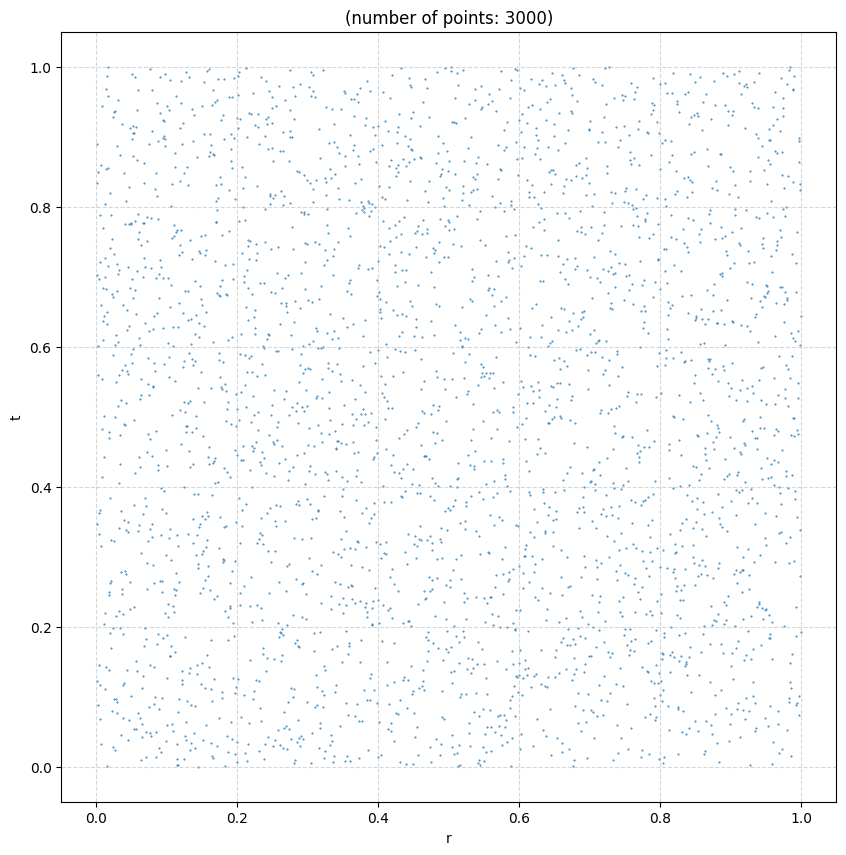

In [285]:
from core.data import Sampler
from core.context import PhysicsContext, cfg
from core.solver import PINNSolver
from utils.visualizer import create_norm_2d_concentration, create_interactive_3d_concentration

device = 'mps'
ctx = PhysicsContext(cfg=cfg, device=device)

solver = PINNSolver(physics_configuration=cfg, device=device, n_pde=3000, layers=4, neurons=128)
solver.pde_training_dataset.plotme()

# solver.prepare_next_stage('uptake')

# solver.train_adam(method='vanilla', epochs=10000, network_lr=0.01)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 1])
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

# solver.train_lbfgs(epochs=200, lr=0.001)
# create_norm_2d_concentration('cf', solver, timestamps=[0, 1])
# create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)



In [ ]:
%load_ext autoreload
%autoreload 2
from core.solver import PINNSolver
from core.context import cfg

solver = PINNSolver(physics_configuration=cfg, device=device, layers=4, neurons=128) 

In [ ]:
t_end=24

solver.prepare_next_stage('uptake')
solver._shift_dataset_boundaries(t_start=0, t_end=t_end/24)

solver.train_adam(epochs=5000, network_lr=0.001)
create_norm_2d_concentration('cf', solver, timestamps=[0, t_end])
create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)


In [ ]:
from utils.visualizer import create_norm_2d_concentration, create_interactive_3d_concentration

create_norm_2d_concentration(what='ci', solver=solver, timestamps=[0, 24])
create_interactive_3d_concentration(n_r=100, n_t=100, solver=solver)

In [ ]:
new_weights = {
    'eq_f': 1.0,
    'eq_b': 1.0,
    'eq_i': 1.0
}

with torch.no_grad():
    for k, v in new_weights.items():
        solver.ctx.pde_weights[k].copy_(v)

print(solver.ctx.get_pde_weights())

solver.train_adam(epochs=5000, network_lr=0.001)



In [ ]:
create_norm_2d_concentration('cf', solver, timestamps=[0, 4, 12, 16, 20, 24])
create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)

In [ ]:
op = torch.optim.Adam(params=solver.approximator.parameters())
op.param_groups[0]['params'][-1]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R = 200
r_nodes = 100

f = lambda r: (0.44 * r**3.2 + 0.56)

r_norm = np.linspace(0, 1, r_nodes)
y = f(r_norm)

plt.plot(r_norm * R, y)
plt.title('fraction of spheroid volume accessible to Ab')
plt.xlabel("r (μm)")
plt.ylabel("phi")
plt.show()


In [ ]:
from core.data import Sampler
from core.model import PINN
pinn = PINN(3, 16, seed=42).to('mps')

sampler = Sampler()
pde_dataset = sampler.sample_interior_dataset(2000)
print(len(pde_dataset))


In [ ]:
from physics.residuals_ver3 import Physics
from core.context import PhysicsContext, cfg

ctx = PhysicsContext(cfg, 'mps')
physics = Physics(context = ctx)
physics.compute_interstitium_residual(norm_dataset=pde_dataset, model=pinn)



In [ ]:
import numpy as np

from core.solver import PINNSolver
from core.context import cfg

from utils.visualizer import create_norm_2d_concentration

solver = PINNSolver(physics_configuration=cfg, layers=4, neurons=128)
# solver.prepare_next_stage('uptake')
print('initial cond at the beginning: ', solver.initial_condition)

num_windows = 12
time_boundaries = np.linspace(0, 1, num_windows + 1)

for i in range(num_windows):
    t_start, t_end = time_boundaries[i], time_boundaries[i+1]
    solver.prepare_next_domain_window(t_start=t_start, t_end=t_end)
    solver.train_adam(epochs=2000, network_lr=0.001)
    # solver.train_lbfgs(epochs=200)

create_norm_2d_concentration('cf', solver, timestamps=[0, 4, 12, 24])

In [ ]:
solver.save_checkpoint('time_marching')



In [ ]:
ar = np.array(([1, 2],
          [3, 4]))
ar[0][1]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

aplha = 0.01
L = 1.0
nx = 10
dx = L / (nx - 1)
nt = 2000
dt = 0.0005
time_steps = 50
x = np.linspace(0, L, nx)

u_initial = np.exp(-100 * (x - 0.05)**2)

diag = [[-2] * nx, [1] * (nx -1), [1] * (nx - 1)] 
A = diags(diagonals=diag, offsets=[0, -1, 1], shape=(nx, nx)).toarray()
A[0, 0] =  A[-1, -1] = 1
A[0, 1] = A[-1, -2] = 0

u = u_initial.copy()

for t in range(nt):
    b = u + aplha * dt / dx**2 * np.dot(A, u)

    u = spsolve(A, b)

    if t % time_steps == 0:
        plt.plot(x, u, label=f"t = {t * dt:.3f}")

plt.legend()

# plt.figure(figsize=(8, 5))
# plt.plot(x, u_initial, label='Initial Condition')

In [ ]:
from scipy.integrate import solve_ivp

aplha = 0.01
Lx, Ly = 1.0, 1.0
nx, ny = 50, 50
dx, dy = Lx / (nx - 1), Ly / (ny - 1)
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)

X, Y = np.meshgrid(x, y)

u_initial = np.exp(-100 * ((X - 0.5)**2 + (Y - 0.5)**2)).flatten()

def heat_diff_2d(t,u):
    u = u.reshape((nx, ny))

    dudx2 = np.zeros_like(u)
    dudy2 = np.zeros_like(u)

    # Compute second derivatives using finite differences
    dudx2[1:-1, :] = (u[2:, :] - 2 * u[1:-1, :] + u[:-2, :]) / dx**2
    dudy2[:, 1:-1] = (u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2]) / dy**2

    return (aplha * (dudx2 + dudy2)).flatten()

t_span = (0, 0.05)
t_eval = np.linspace(t_span[0], t_span[1], 200)

sol = solve_ivp(fun=heat_diff_2d, t_span=t_span, y0=u_initial, method='RK45', t_eval=t_eval)

for i in range(0, len(sol.t), 10):
    plt.figure()
    u_plot = sol.y[:, i].reshape((nx, ny))
    plt.contourf(X, Y, u_plot, 20, cmap='hot')
    plt.colorbar(label='Temperature')
    plt.title(f"2D Heat Diffusion at t = {sol.t[i]:.3f} seconds")
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Smax, T = 8, 6
K = 3 # cost
sigma = 0.06
r = 0.08

m = 200
h = Smax / m
x = h * np.arange(m+1) # stock price

n = 1000
tau = T / n
t = tau * np.arange(n+1)
lamb, mu = tau / h**2, tau / h

V = np.zeros([m+1, n+1])
V[:, 0] = np.maximum(0, x - K)

for j in range(n):
    Vfict = 2 * h + V[m-1, j]
    Vj = np.hstack([V[:, j], Vfict])
    if j % 10 == 0:
        print(f"Vfict: {Vfict}")
        print(f"Vj at time {t[j]:.2f}:\n{Vj.shape}\n")

    for i in range(1, m+1):
        diff1 = Vj[i+1] - Vj[i-1]
        diff2 = Vj[i+1] - 2*Vj[i] + Vj[i-1]
        V[i, j+1] = (
            Vj[i]
            + (lamb * sigma**2 * x[i] ** 2 / 2) * diff2
            + (r * x[i] * mu) / 2 * diff1
            - r * tau * Vj[i]
        )
select_times = 250 * np.arange(5)
show_times = t[select_times]

for j, col in enumerate(select_times):
    print(j, col)
    plt.plot(x, V[:, col], label=f"t={show_times[j]:.1f}")

In [ ]:
from numpy import diff

from core.context import cfg

# IVBVP for diffucion-only case - (binding antibody)

# Parameters.
R, T = 1.0, 1.0
D = 8.38
P = 2.5e-4
C0 = 60

fun_phi = lambda r: (0.44 * r**3.2 + 0.56)

# space and time discretization.
m = 200
h = R / m
r = h * np.arange(m+1)
print(f"r:\n{r.shape}")
phi = fun_phi(r)
# phi_r = []
# for i in range(1, m+1):
#     phi_r.append((phi[i] - phi[i-1]) / h)

print(f"phi:\n{phi.shape}")
# print(f"phi_r:\n{np.array(phi_r).shape}, {phi_r}")

n = 1000
tau = T / n
t = tau * np.arange(n+1)
mu, lamb = tau / h**2, tau / h

C = np.zeros((m+1, n+1))
print(f"C:\n{C.shape}")
C[:, 0] = 0 # initial condition
print(f"Initial C:\n{C[:, 0]}")

for j in range(n):
    C[:, j] = C[:, j] / phi
    U = C
    Ufict = U[m-1, j] + P * 2 * h / D / phi[m] * (C0 - U[m-1, j])  # has idx 201
    Uj = np.hstack((U[:, j], Ufict))
    Uj[1] = Uj[0] # Neumann BC at r=0
    phij = np.hstack((phi, fun_phi(R))) # has idx 201
    for i in range(1, m+1): # i from 1 to 201
        diff_phi = phi[i+1] - phi[i-1] if i < m else phi[i] - phi[i-1]
        diff_U = Uj[i+1] - Uj[i-1]
        diff_U2 = Uj[i+1] - 2 * Uj[i] + Uj[i-1]
        print(f"i: {i}, j: {j}, diff_phi: {diff_phi}, Uj: {Uj[i]}, diff_U: {diff_U}, diff_U2: {diff_U2}")
        U[i, j+1] = U[i, j] + lamb * (2/(r[i]) + 1/h/phi[i] * diff_phi) * diff_U + mu * diff_U2
        
U
print(f'Uj : {Uj.shape}\n{Uj}')

In [ ]:
r[200]

In [ ]:
import matplotlib.pyplot as plt

f = lambda x: np.sin(np.pi * x)
x = np.linspace(-1, 0, 50)



n = 4
a, b = -1, 0
h = (b - a) / n
x = a + np.arange(n+1) * h
print(x)
# plt.scatter(x, f(x))

u_pred = [-3.142, -2.221, 0, 2.221, 3.142]
u_true = lambda x: np.pi * np.cos(np.pi * x)
plt.figure(figsize=(8, 5))
plt.scatter(x, u_pred, label='Predicted', marker='x', s=100)
plt.scatter(x, u_true(x), label='True')
plt.legend()

In [ ]:
Dx = np.zeros((5, 5))
Dx[0, 0], Dx[0, 1], Dx[0, 2] = -3/2, 2, -1/2
Dx[1, 0], Dx[1, 1], Dx[1, 2] = -1/2, 0, 1/2
Dx[2, 1], Dx[2, 2], Dx[2, 3] = -1/2, 0, 1/2
Dx[3, 2], Dx[3, 3], Dx[3, 4] = -1/2, 0, 1/2
Dx[-1, -1] = 3/2

u_pred = 4 * Dx @ f(x)
plt.figure(figsize=(8, 5))
plt.scatter(x, u_pred, label='Predicted', marker='x', s=100)
plt.scatter(x, u_true(x), label='True')
plt.legend()

In [ ]:

def diffmat2(n, a, b):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)

    super_diag = np.ones(n)
    main_diag = -2 * np.ones(n+1)
    sub_diag = np.ones(n)

    Dxx = np.diag(main_diag, k=0) + np.diag(super_diag, k=1) + np.diag(sub_diag, k=-1)
    Dxx[0, :4] = np.array([2, -5, 4, -1])
    Dxx[-1, -4:] = np.array([-1, 4, -5, 2])

    # print(Dxx)
    # print(Dxx.shape)
    return x, Dxx / h**2

def diffmat1(n, a, b):
    h = (b - a) / n
    x = np.linspace(a, b, n+1)

    super_diag = 0.5 * np.ones(n)
    main_diag = 0 * np.ones(n+1)
    sub_diag = -0.5 * np.ones(n)

    Dx = np.diag(main_diag, k=0) + np.diag(super_diag, k=1) + np.diag(sub_diag, k=-1)
    Dx[0, :3] = np.array([-1.5, 2, -0.5])
    Dx[-1, -3:] = np.array([0.5, -2, 1.5])

    # print(Dx)
    # print(Dx.shape)
    return x, Dx / h


In [ ]:
f = lambda x: x + np.exp(np.sin(4 * x))
a = -1
b = 1
n = 50
x, Dx = diffmat1(n, a, b)
_, Dxx = diffmat2(n, a, b)

f_x_true = 1 + 4 * np.cos(4 * x) * np.exp(np.sin(4 * x))
f_xx_true = lambda x: 16 * np.exp(np.sin(4 * x)) * (np.cos(4 * x)**2 - np.sin(4 * x))

f_x = Dx @ f(x)
f_xx = Dxx @ f(x)

plt.figure(figsize=(8, 5))
plt.subplot(3, 1, 1)
plt.scatter(x, f(x), label='f(x)', color='blue')
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(x, f_x_true, label="f'(x) true", color='green')
plt.plot(x, f_x, label="f'(x)", color='red')
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(x, f_xx_true(x), label="f''(x) true", color='orange')
plt.plot(x, f_xx, label="f''(x)", color='green')
plt.legend()
plt.show()


In [ ]:
f = lambda t, u: np.sin((u + t)**2)
tspan = [0, 4]

eval_nodes = 100
t_eval = np.linspace(tspan[0], tspan[1], eval_nodes)
u0 = np.array([-1.0])

from scipy.integrate import solve_ivp
sol = solve_ivp(fun=f, t_span=tspan, y0=u0, dense_output=True)

In [ ]:
# plt.plot(sol.t, sol.y, label='Numerical Solution')
plt.plot(sol.t, sol.y[0, :])


In [ ]:
t_eval = np.linspace(0, 4, 20)
for t in t_eval:
    print(f'u({t:.2f}) =  {sol.sol(t)[0]:.4f}')
    plt.scatter(t, sol.sol(t)[0], color='red')

sol.message

In [ ]:
rhs = lambda u, t:(u + t)**2
sol = solve_ivp(rhs, [0.0, 1.0], [1.0])
sol.message

In [ ]:
plt.semilogy(sol.t, sol.y[0, :])

In [ ]:
t = np.linspace(0, 3, 20)
u = np.array([np.exp(-t) * u0 for u0 in [1., 1.3, 5]])
plt.plot(t, u.T)

u

In [ ]:
from numpy import finfo


finfo(float).eps

In [ ]:
lamb = 1.1
def ode(r, y):
    l = [y[1],
         lamb / y[0] - y[1] / r]
    return np.array(l)

def bc(ya, yb):
    return np.array([
        ya[1],
        yb[0] - 1
    ])

a, b = finfo(float).eps, 1.0
r = np.linspace(a, b, 100)
w = np.ones(r.size)
dw_dr = np.zeros(r.size)
y_init = np.vstack([w, dw_dr])  # y_init[0] --> w , y_init[1] --> dw_dr

from scipy.integrate import solve_bvp
sol = solve_bvp(ode, bc, r, y_init)
print(sol.message)
print(f'nodes used: {sol.x.size}')

In [ ]:
plt.plot(sol.x, sol.y[0])

In [ ]:
def diff_matrix(n, a, b, sub, main, sup, order):
    
    h = (b - a) / n
    x = a + np.arange(n) * h

    d_sub = np.ones(n) * sub 
    d_main = np.ones((n+1)) * main
    d_sup = np.ones(n) * sup

    mat = np.diag(d_main, k=0) + np.diag(d_sub, k=-1) + np.diag(d_sup, k=1)
    
    print(f'\ndiff_mat order {order}: {mat.shape} -->')
    if order == 2:
        return x, h, mat
    elif order == 1:
        return x, h, mat


In [ ]:
n = 100

x, h, Dxx = diff_matrix(n=n, a=0, b=1, sub=1, main=-2, sup=1, order=2)
Dxx[0, -1], Dxx[-1, 0] = 1 / h**2, 1 / h**2
print(Dxx)

_, h, Dx = diff_matrix(n=n, a=0, b=1, sub=-0.5, main=0, sup=0.5, order=1)
Dx[0, -1], Dx[-1, 0] = -1 / (2 * h), 1 / (2 * h)
print(Dx)

In [ ]:
def create_diag_matrix(nodes, sub, main, sup):
    d_sub = np.ones(nodes - 1) * sub 
    d_main = np.ones((nodes)) * main
    d_sup = np.ones(nodes - 1) * sup

    mat = np.diag(d_main, k=0) + np.diag(d_sub, k=-1) + np.diag(d_sup, k=1)
    return mat

def create_periodic_diff_matrises(n, a, b):
    '''n: number of unique nodes, a: left boundary, b: right boundary'''
    h = (b - a) / n
    x = a + np.arange(n) * h

    Dx = create_diag_matrix(nodes=n, sub=-0.5, main=0, sup=0.5)
    Dx[0, -1], Dx[-1, 0] = -1 , 1 
    print(f'Created periodic first-derivative differentiation matrix with {n} nodes, h={h:.4f}')

    Dxx = create_diag_matrix(nodes=n, sub=1, main=-2, sup=1)
    Dxx[0, -1], Dxx[-1, 0] = 1 , 1 
    print(f'Created periodic second-derivative differentiation matrix with {n} nodes, h={h:.4f}')

    return x, Dx / (2 * h), Dxx / h**2

x, Dx, Dxx = create_periodic_diff_matrises(n=3, a=0, b=1)

In [ ]:
plot = False

m = 100 # number of space nodes
x, Dx, Dxx = create_periodic_diff_matrises(m, a=0, b=1)

t_final = 0.15
n = 6600 # number of time steps
tau = (t_final - 0) / n
t = np.arange(n + 1) * tau # time vector

U = np.zeros((m, n+1)) # the solution vector, each column is the solution at a time step
ic = lambda x: np.exp(-60 * (x - 0.5)**2)
U[:, 0] = ic(x)
if plot:
    plt.plot(x, U[:, 0], label='Initial Condition')
    plt.legend()
    plt.show()

import scipy.sparse as sp
I = sp.eye(m)
print(I.shape, Dxx.shape)
A = I + tau * sp.csr_array(Dxx)

for j in range(n):
    U[:, j+1] = A @ U[:, j]

plt.plot(x, U[:, ::1000])
plt.legend([f"t={tj:.2f}" for tj in t[::500]])

In [ ]:
printing = True
method = "BDF"

m = 100
x, Dx, Dxx = create_periodic_diff_matrises(n=m, a=0, b=1)
print(f'Shape of Dxx={Dxx.shape}')
print(f'Shape of space vector={x.shape}')
ic = lambda x: np.exp(-60 * (x - 0.5)**2)
y0 = ic(x)
print(f'shape of y0={y0.shape}')

from scipy.integrate import solve_ivp
tfinal = 0.05
rhs = lambda t, u: Dxx @ u
sol = solve_ivp(rhs, [0, tfinal], y0, method=method, dense_output=True)
print(f'message: {sol.message}')
print(f'{method} took {len(sol.t) - 1} steps ')

if printing:
    t = np.linspace(0, t_final, 7)
    plt.plot(x, sol.sol(t))
    print(f'sol shape: {sol.sol(t).shape}')



In [ ]:
import numpy as np

def get_mat(diag_size, sub, main, sup):
    mat = sub * np.diag(np.ones(diag_size-1), k=-1) + main * np.diag(np.ones(diag_size), k=0) + sup * np.diag(np.ones(diag_size-1), k=1) 
    return mat

def compute_diff_matrices(m, a, b):
    '''m: space steps'''
    h = (b - a) / m
    x = a + h * np.arange(m+1)
    Dx = get_mat(diag_size=m+1, sub=-1, main=0, sup=1)
    Dxx = get_mat(diag_size=m+1, sub=1, main=-2, sup=1)
    return x, h, Dx / (2 * h), Dxx / h**2  




In [ ]:
h = (b - a) / m
x = a + h * np.arange(m+1)
Dx = get_mat(diag_size=m+1, sub=-1, main=0, sup=1)
Dxx = get_mat(diag_size=m+1, sub=1, main=-2, sup=1) 


In [ ]:
def compute_diffusion_operator(spatial_steps, x_domain, debug=False):
      m = spatial_steps
      
      D_eff = 18.1008
      P_up = 0.005967
      C_sol = 60

      x, h, Dx, Dxx = compute_diff_matrices(m, x_domain[0], x_domain[1])

      x_inverse = np.zeros_like(x)
      x_inverse[1:] = 1. / x[1:]

      phi = 0.44 * x**3.2 + 0.56
      phi_x = 0.44 * 3.2 * x**2.2

      # Neuman.
      Dx[0, :] = 0 
      Dxx[0, 0] =3 * -2 / h**2
      Dxx[0, 1] = 3 * 2 / h**2  

      # Robin.
      alpha = 2 * h * P_up / D_eff / phi[m]
      Dx[m, m] = -alpha / (2 * h)
      Dx[m, m-1] = 0
      Dxx[m, m] = -(2 + alpha) / h**2
      Dxx[m, m-1] = 2 / h**2

      coef_2 = D_eff * phi[m]
      coef_1 = 2 * D_eff * phi[m] / x[m] + D_eff * phi_x[m]
      b = np.zeros_like(x)
      b[m] = (coef_2 / h**2 + coef_1 / (2 * h)) * alpha * C_sol

      L_u = np.diag(D_eff * phi) @ Dxx + \
            (np.diag(2 * D_eff * phi * x_inverse) + np.diag(D_eff * phi_x)) @ Dx
      
      Phi_inv = np.diag(1.0 / phi)
      L_c = L_u @ Phi_inv
      if debug:
            print(f'step size h: {h}')
            print(f'x: {x.shape}, Dx: {Dx.shape}, Dxx: {Dxx.shape}')
            print(f'x_inv: {x_inverse.shape}')
            print(f'phi: {phi.shape}, phi_x: {phi_x.shape}')
            print(f'alpha: {alpha}')
            print(f'b: {b.shape}')
            print(f'\nDx\n{Dx}\nDxx\n{Dxx}\nb\n{b}')
            print(f'\nL_u: {L_u.shape}\n{L_u}')
            print(f'\nL_cf: {L_c.shape}\n{L_c}')
      return x, L_c, b

In [1]:
# Diffucion only...
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from utils.fdm import get_diffusion_differential_operator

# x, L_cf, b = compute_diffusion_operator(spatial_steps=100, x_domain=[0, 1])
x, L_cf, b = get_diffusion_differential_operator(m=100, x_domain=[0, 1])

C0 = 0 * x # initial condition
tfinal = 1
rhs = lambda t, cf: L_cf @ cf + b
sol = solve_ivp(rhs, [0, tfinal], C0, method='BDF', dense_output=True)
print(sol.message)

t = np.linspace(0, tfinal, 10)
plt.figure(figsize=(8, 5))
plt.plot(x, sol.sol(t))
plt.xlabel('x')
plt.ylabel('C(x, t)')
plt.title("diffucion only")
plt.legend([f"t={(tj*24):.2f}h" for tj in t])

TypeError: get_diffusion_differential_operator() missing 2 required positional arguments: 'ctx' and 'phase'

In [2]:
# Makes sure that the notebook is reloaded when changes are made to other files in the project
%load_ext autoreload
%autoreload 2

from core.context import PhysicsContext

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from utils.fdm import get_diffusion_differential_operator


def run_fdm(m, ctx: PhysicsContext, phase_name, y0, binding, t_final=1.0):
    N = m + 1
    # y0 = np.zeros(3 * N) 
    x, L_cf, b = get_diffusion_differential_operator(m=m, x_domain=[0, 1], ctx=ctx, phase=phase_name)

    def uptake_rhs(t, y, N):
        cf = y[:N]
        cb = y[N:2*N]
        ci = y[2*N:]

        # take the none-dimentional params for each phase.
        pi = ctx.pi[phase_name] 
        if binding:
            k_on1 = pi['on1'] 
            k_off1 = pi['off1'] 
            k_on2 = pi['on2'] 
            k_off2 = pi['off2'] 
            k_int = pi['int'] 
        else: 
            k_on1 = k_on2 = k_off1 = k_off2 = k_int = 0.0 
        
        # real-scenario configuration. values to be sure...
        # k_on1 = 54191.7148
        # k_off1 = 6105.6001
        # k_on2 = 3067.4556
        # k_off2 = 345.600
        # k_int = 1.2096

        # configuration to see the impact of the other terms than diffucion.
        # k_on1 = 1.0
        # k_off1 = 1.0
        # k_on2 = 1.0
        # k_off2 = 1.0
        # k_int = 1.0
        
        # diffucion-only configuration.
        # k_on1 = 0.0
        # k_off1 = 0.0
        # k_on2 = 0.0
        # k_off2 = 0.0
        # k_int = 0.0
        
        phi = 0.44 * x**3.2 + 0.56
        Rt = 1060

        diffusion = L_cf @ cf + b
        reaction1 = k_on1 * cf/phi * (1 - cb) - k_off1 * cb
        reaction2 = k_on2 * cf/phi * (1 - cb) - k_off2 * cb
        internalization = k_int * cb

        cf_t = diffusion - reaction1
        cb_t = reaction2 - internalization
        ci_t = internalization

        return np.concatenate([cf_t, cb_t, ci_t]) 

    sol = solve_ivp(
        fun=uptake_rhs,
        t_span=[0, t_final],
        y0=y0,
        method='BDF',
        args=(N,),
        dense_output=True
    )
    print(f'[{phase_name}]\nsolver message: {sol.message}')
    return x, sol

def plot_solution_at_phase(x, sol, time_splits, phase_name:str, ctx:PhysicsContext):
    t = np.linspace(0, 1.0, time_splits)
    tau = ctx.tau[phase_name]
    time_scale = 'sec' if phase_name == 'fishing' else 'h'
    if phase_name == 'fishing':
        tau = tau * 3600
    plt.figure(figsize=(8, 5))
    plt.plot(x, sol.sol(t)[:101, :])
    plt.xlabel('Normalized distance from center')
    plt.ylabel('C(r, t)')
    plt.title(f"binding antibody - {phase_name}")
    plt.legend([f"t={(tj*tau):.2f}{time_scale}" for tj in t])
    plt.show()


In [4]:
from utils.fdm import get_diffusion_differential_operator, run_fdm


m = 2
N = m+1
x, L_cf, b = get_diffusion_differential_operator(m=m, x_domain=[0, 1], debug=False)
y0_uptake = np.zeros((3 * (m+1)))


sol_uptake = run_fdm(
    y0=y0_uptake,
    t_final=1.0,
    args=(N, x, L_cf, b)
)

TypeError: get_diffusion_differential_operator() missing 2 required positional arguments: 'ctx' and 'phase'

In [ ]:
from scipy.integrate import solve_ivp
from utils.fdm import get_diffusion_differential_operator, uptake_rhs

m = 100

N = m + 1
y0 = np.zeros(3 * N)
t_final = 1.0
x, L_cf, b = get_diffusion_differential_operator(m=m, x_domain=[0, 1])

sol = solve_ivp(
    fun=uptake_rhs,
    t_span=[0, t_final],
    y0=y0,
    method='BDF',
    args= (N, x, L_cf, b)
    
)
print(sol.message)
    

In [ ]:
R = 200     # μm
tau = 24    # h
t_sec = tau * 3600

D = 8.38     # μm^2 / sec
k_off = 4e-3 # 1 / sec
k_d = 6.76   # 1 / nM
k_on = k_off / k_d # 1 / nM / sec

R_t = 1060 # nM
C_sol = 60 # nM


hat_params = {
    'D': t_sec / R**2 * D,
    'k_on': t_sec * R_t * k_on,
    'k_off': t_sec * R_t/C_sol * k_off
}

hat_params

In [ ]:
# Makes sure that the notebook is reloaded when changes are made to other files in the project
%load_ext autoreload
%autoreload 2

from core.context import PhysicsContext, cfg
ctx = PhysicsContext(cfg=cfg)

# 1.switch context.
def switch_params(ctx: PhysicsContext, phase):
    return {
        'pi' : ctx.pi[phase], # dimentionless params.
        'tau' : ctx.tau[phase],
        'P' : ctx.P[phase],
        'C_sol': ctx.C_sol[phase]
    } 
# 2.get new initial condition.

# 3.solve_ivp.
p = switch_params(ctx, 'fishing')
p

[uptake]
solver message: The solver successfully reached the end of the integration interval.
shape of sol.y:  (303, 237)
pi values
{'D': 18.100800000000003, 'K_on': 51.124260355029584, 'K_off': 345.6, 'K_int': 1.2096, 'P': 0.108}


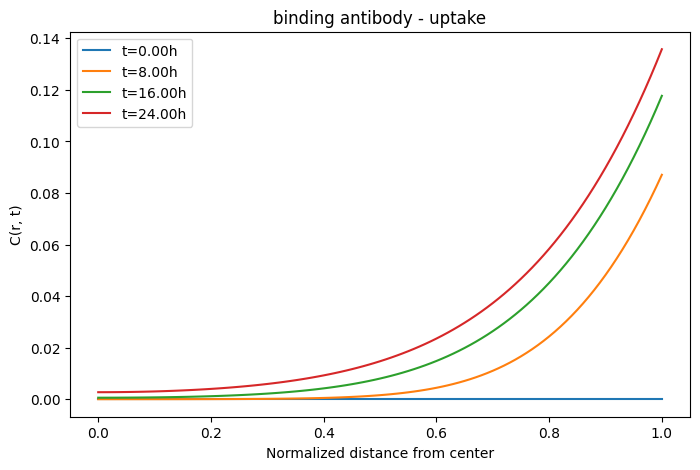

[clearance]
solver message: The solver successfully reached the end of the integration interval.
shape of sol.y:  (303, 133)
pi values
{'D': 18.100800000000003, 'K_on': 51.124260355029584, 'K_off': 345.6, 'K_int': 1.2096, 'P': 0.00011232}


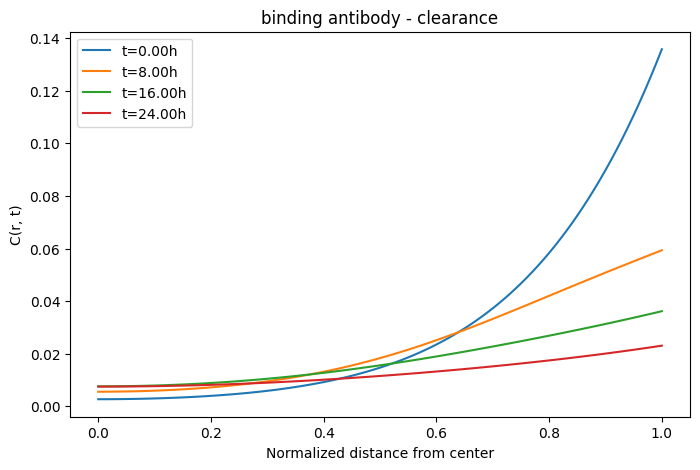

In [9]:
from core.context import PhysicsContext, cfg
from utils.fdm import run_phase

context = PhysicsContext(cfg)
m = 100     # number of steps.
N = m + 1   # number of spatial nodes.
y0_up = np.zeros(3 * N)     # initial condition for uptake phase.
sol_up, final_up = run_phase(m=m, phase_name='uptake', y0=y0_up, ctx=context, time_splits=4, t_final=1.0)
# sol_fi, final_fi = run_phase(m=m, phase_name='fishing', y0=final_up, ctx=context, time_splits=3, t_final=1.0)
sol_cl, _ = run_phase(m=m, phase_name='clearance', y0=final_up, ctx=context, time_splits=4, t_final=1.0)

In [ ]:
x, L, b = get_diffusion_differential_operator(m=10, x_domain=(0, 1), ctx=context, phase='uptake')


In [ ]:
from core.simple_context import compute_non_dimentional_params

pi_up = compute_non_dimentional_params('clearance')
pi_up

{'D': 18.100800000000003, 'K_on': 51.124260355029584, 'K_off': 345.6, 'K_int': 1.2096, 'P': 0.108}

🚀 [STAGE START] Running: train_adam
🎯 Target: 10000 epochs


Training PINN:   0%|          | 0/10000 [00:00<?, ?epoch/s]

,epoch,total,pde_f,pde_b,pde_i,center,surface,ic_f,ic_b,ic_i
0,0,3.9280e+09,4.7204e+08,3.4560e+09,7.1049e-01,5.4137e-03,1.7479e+00,5.1662e-01,4.9651e-01,4.7175e-01
1,200,2.1948e+04,4.1524e+03,1.7783e+04,5.3641e+00,7.2450e-06,1.3477e-01,7.7253e-05,2.6020e+00,3.7209e+00
2,400,1.9348e+04,3.6950e+03,1.5637e+04,8.0022e+00,5.9614e-06,1.3457e-01,7.2458e-05,2.4810e+00,5.5602e+00
3,600,1.6600e+04,3.2084e+03,1.3369e+04,1.2315e+01,4.6801e-06,1.3433e-01,6.7149e-05,2.3444e+00,8.5618e+00
4,800,1.4033e+04,2.7452e+03,1.1255e+04,1.8211e+01,3.5628e-06,1.3408e-01,6.1925e-05,2.2062e+00,1.2656e+01
5,1000,1.1768e+04,2.3298e+03,9.3940e+03,2.5065e+01,2.6518e-06,1.3383e-01,5.7066e-05,2.0747e+00,1.7400e+01
6,1200,9.8247e+03,1.9688e+03,7.7998e+03,3.1874e+01,1.9366e-06,1.3359e-01,5.2684e-05,1.9542e+00,2.2096e+01
7,1400,8.1756e+03,1.6597e+03,6.4503e+03,3.7565e+01,1.3876e-06,1.3336e-01,4.8801e-05,1.8468e+00,2.6002e+01
8,1600,6.7792e+03,1.3964e+03,5.3111e+03,4.1273e+01,9.7273e-07,1.3314e-01,4.5398e-05,1.7529e+00,2.8524e+01
9,1800,5.5926e+03,1.1717e+03,4.3473e+03,4.2518e+01,6.6330e-07,1.3294e-01,4.2440e-05,1.6727e+00,2.9338e+01


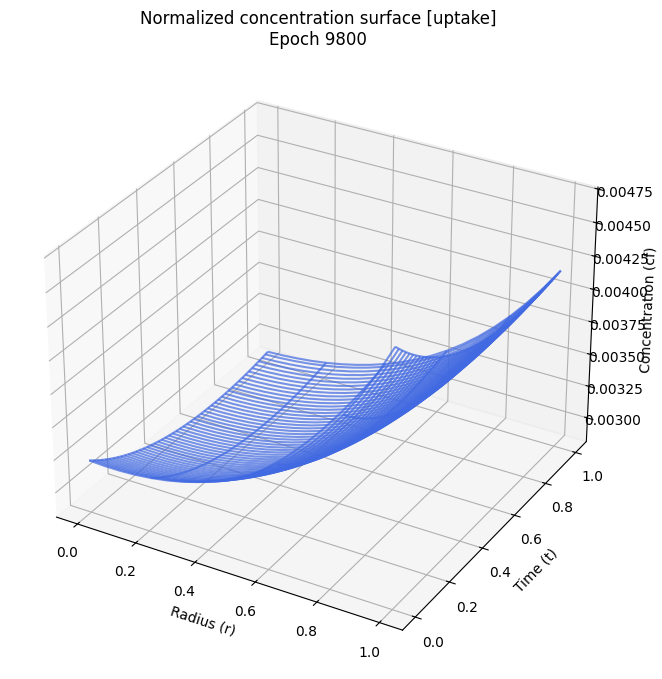


✅ Optimizer intantiated
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
✅ [STAGE DONE] Completed in 484.65s
💾 Checkpoint saved: checkpoints/pinn_train_adam_uptake.pt


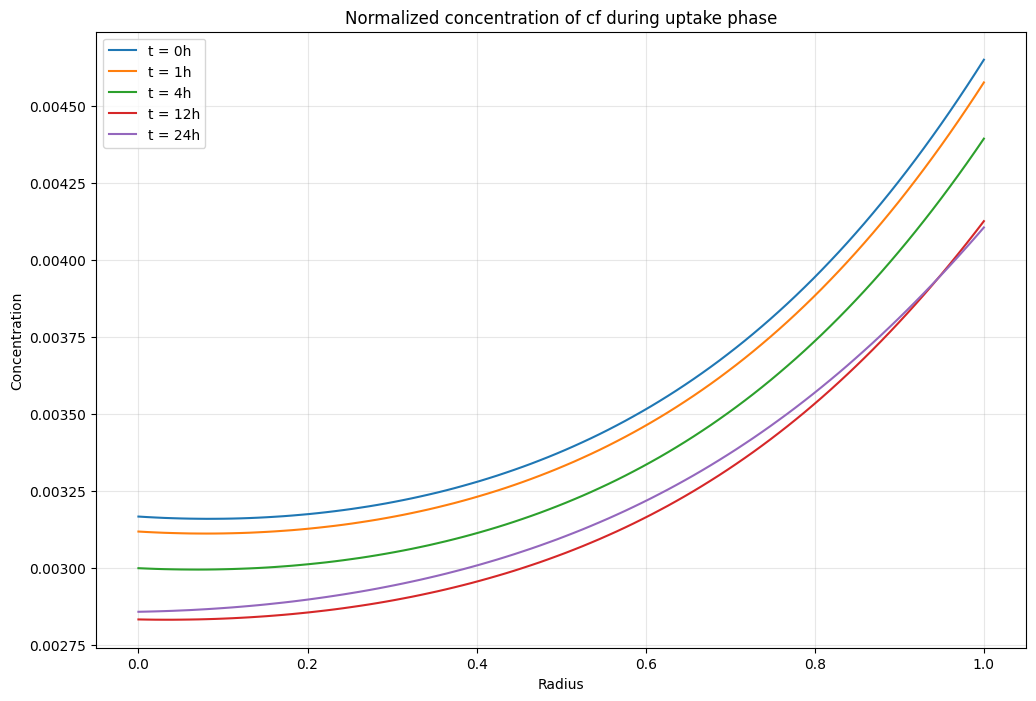

In [104]:
from core.context import cfg
from core.solver import PINNSolver
from utils.visualizer import create_norm_2d_concentration, create_interactive_3d_concentration

context = PhysicsContext(cfg)
print(context.get_dimentionaless_params('uptake'))
solver = PINNSolver(cfg, 'mps', 42, n_pde=2000, layers=4, neurons=128)
solver.train_adam(epochs=10000)

create_norm_2d_concentration('cf', solver, timestamps=[0, 1, 4, 12, 24])
create_interactive_3d_concentration(n_r=20, n_t=100, solver=solver)


🚀 [STAGE START] Running: train_adam
🎯 Target: 10000 epochs


Training PINN:   0%|          | 0/10000 [00:00<?, ?epoch/s]

,epoch,total,pde_f,pde_b,pde_i,center,surface,ic_f,ic_b,ic_i
0,0,5.4887e+01,9.4286e+00,4.5285e+01,3.0204e-02,1.6365e-07,1.2715e-01,4.2339e-08,9.9823e-03,5.7051e-03
1,200,3.9239e+02,4.0409e+01,3.5185e+02,3.4808e-03,3.2337e-06,1.2666e-01,2.0759e-07,4.3915e-03,7.0835e-05
2,400,1.2194e+02,9.8189e+00,1.1198e+02,3.2095e-03,5.5617e-07,1.2711e-01,1.2913e-07,5.0229e-03,1.3775e-04
3,600,3.2011e+01,1.8522e+00,3.0022e+01,3.0125e-03,2.5758e-08,1.2739e-01,1.1200e-07,5.4693e-03,1.9581e-04
4,800,1.3939e+01,1.3331e+00,1.2469e+01,2.8315e-03,8.9471e-08,1.2751e-01,1.1140e-07,5.6126e-03,2.3078e-04
5,1000,1.0555e+01,1.4702e+00,8.9488e+00,2.6548e-03,1.5348e-07,1.2755e-01,1.1237e-07,5.5637e-03,2.4975e-04
6,1200,9.0606e+00,1.3812e+00,7.5436e+00,2.4778e-03,1.7280e-07,1.2756e-01,1.1260e-07,5.4358e-03,2.6290e-04
7,1400,7.9009e+00,1.2212e+00,6.5443e+00,2.3008e-03,1.7806e-07,1.2757e-01,1.1220e-07,5.2812e-03,2.7521e-04
8,1600,6.9377e+00,1.0728e+00,5.7298e+00,2.1259e-03,1.8150e-07,1.2757e-01,1.1116e-07,5.1142e-03,2.8791e-04
9,1800,6.1330e+00,9.4905e-01,5.0491e+00,1.9556e-03,1.8500e-07,1.2757e-01,1.0938e-07,4.9373e-03,3.0092e-04


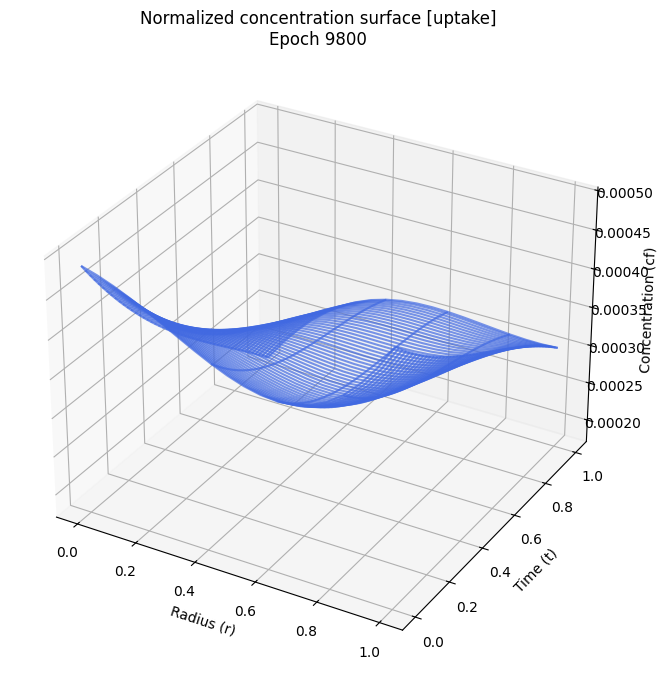


✅ Optimizer intantiated
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
✅ [STAGE DONE] Completed in 364.05s
💾 Checkpoint saved: checkpoints/pinn_train_adam_uptake.pt


,loss,weights,parameters
total,"[54.88714599609375, 33814.87109375, 14867230.0...",NaN,NaN
pde_f,"[9.428624153137207, 2951.587646484375, 1800250...",NaN,NaN
pde_b,"[45.28548049926758, 30863.125, 13066980.0, 256...",NaN,NaN
pde_i,"[0.030204350128769875, 0.01932084746658802, 0....",NaN,NaN
center,"[1.636507249713759e-07, 4.0310987969860435e-05...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN
surface,"[0.1271463930606842, 0.13182060420513153, 0.08...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN
ic_f,"[4.233868722280931e-08, 2.006057684411644e-06,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN
ic_b,"[0.009982285089790821, 0.006350533105432987, 0...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN
ic_i,"[0.005705084651708603, 0.0019314949167892337, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN
eq_b,NaN,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",NaN


In [101]:
solver.train_adam(epochs=10000)

In [ ]:
import deepxde as dde

No backend selected.
Finding available backend...
Found pytorch
Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
import matplotlib.pyplot as plt

# dataset = dde.geometry.sample(2000, 2, 'Hammersley')
# plt.scatter(dataset[:, 0], dataset[:, 1], s=0.1)

geom = dde.geometry.Interval(0,  1)
timedomain = dde.geometry.TimeDomain(0, 1)
geotime = dde.geometry.GeometryXTime(geom, timedomain)


array([[0. , 1. ],
       [1. , 1. ],
       [0. , 0.8],
       [1. , 0.8],
       [0. , 0.6],
       [1. , 0.6],
       [0. , 0.4],
       [1. , 0.4],
       [0. , 0.2],
       [1. , 0.2]], dtype=float32)

In [129]:
np.max(dataset[:, 0])

np.float32(0.9999695)

In [301]:
import deepxde as dde
from deepxde.backend import pytorch
import numpy as np
import matplotlib.pyplot as plt

# utilities
def get_layer_size(i, h, n, o):
    return [i] + [n] * h + [o]

def scatter_collocation_points(data: dde.data.TimePDE):
    x = data.train_x_all
    x_coor = x[:, 0:1]
    t_coor = x[:, 1:]
    plt.figure(figsize=(8, 8))
    plt.scatter(x_coor, t_coor, s=0.1)
    plt.xlabel('Time (t)')
    plt.ylabel('Space (x)')
    plt.title(f'Collocation points (Total: {len(x)}) - distribution: {data.train_distribution}')
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.show()

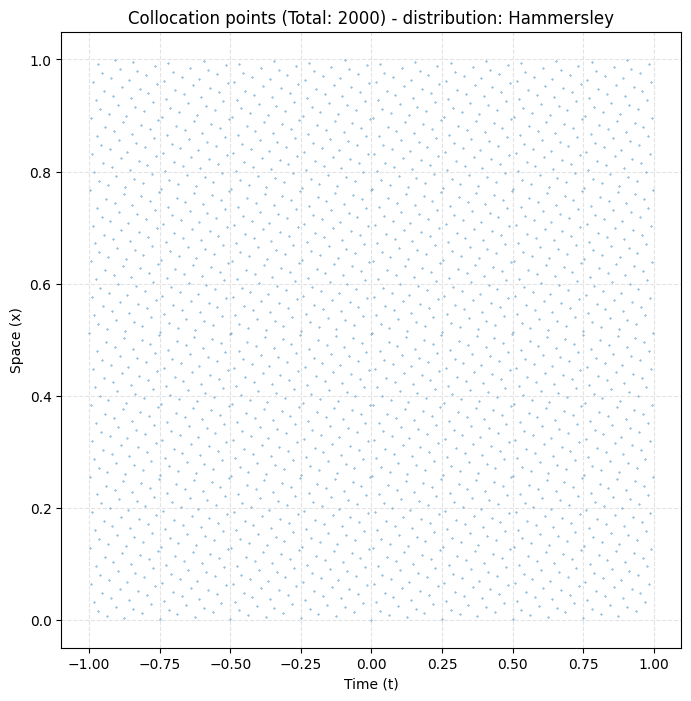

Compiling model...
'compile' took 0.005634 s

Training model...

Step      Train loss    Test loss     Test metric   
0         [2.10e+01]    [2.09e+01]    [6.58e-01]    
500       [2.61e-01]    [2.53e-01]    [5.31e+00]    
1000      [1.84e-02]    [1.71e-02]    [5.24e+00]    
1500      [4.84e-03]    [4.61e-03]    [5.23e+00]    
2000      [1.89e-03]    [1.82e-03]    [5.22e+00]    
2500      [8.51e-04]    [8.24e-04]    [5.22e+00]    
3000      [4.55e-04]    [4.43e-04]    [5.22e+00]    
3500      [2.86e-04]    [2.81e-04]    [5.22e+00]    
4000      [1.96e-04]    [1.94e-04]    [5.22e+00]    
4500      [1.38e-04]    [1.37e-04]    [5.22e+00]    
5000      [9.79e-05]    [9.83e-05]    [5.22e+00]    
5500      [7.08e-05]    [7.23e-05]    [5.22e+00]    
6000      [5.01e-05]    [5.14e-05]    [5.22e+00]    
6500      [3.66e-05]    [3.80e-05]    [5.22e+00]    
7000      [2.75e-05]    [2.89e-05]    [5.22e+00]    
7500      [2.17e-05]    [2.30e-05]    [5.22e+00]    
8000      [1.76e-05]    [1.88e-05]

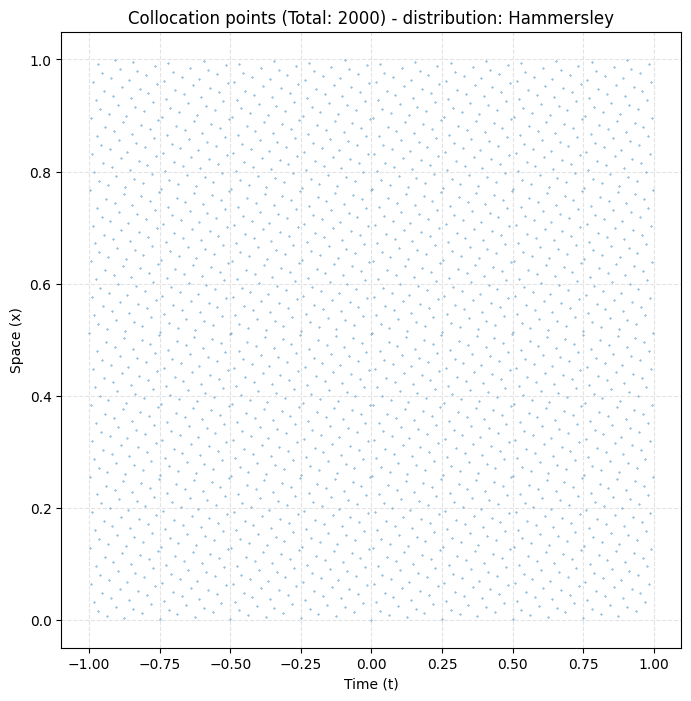

Saving loss history to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/loss.dat ...
Saving training data to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/train.dat ...
Saving test data to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/test.dat ...


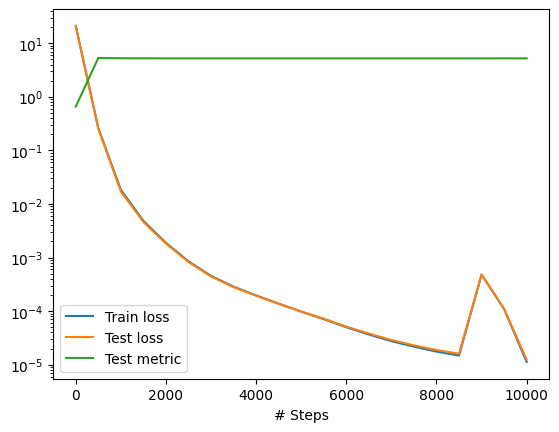

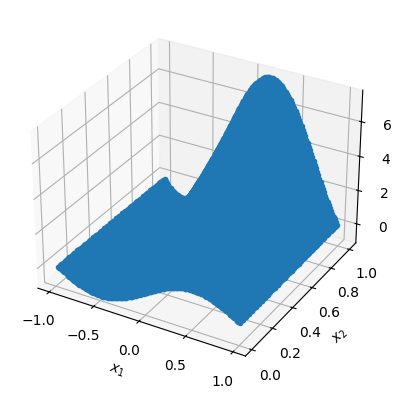

In [302]:
# Define the computational geometries of the prblem.
geom = dde.geometry.Interval(-1, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geometry=geom, timedomain=timedomain)

# Define the PDE residual 
def pde(x, y):
    dy_t = dde.grad.jacobian(y, x, j=0)
    dy_xx = dde.grad.hessian(y, x, j=1)
    return (
        dy_t - dy_xx + torch.exp(-x[:, 1:2]) * (torch.sin(np.pi * x[:, 0:1]) - np.pi**2 * torch.sin(np.pi * x[:, 0:1]))
    )

# Define the reference solution (true solution).
def func(x):
    return np.exp(-x[:, 1:]) * np.sin(np.pi * x[:, 0:1])

# Define TimePDE problem.
data = dde.data.TimePDE(geomtime, pde, [], num_domain=2000, train_distribution='Hammersley', solution=func, num_test=10000)
scatter_collocation_points(data)

# Chose the network.
layer_size = get_layer_size(2, 3, 32, 1)
net = dde.nn.FNN(layer_size, "tanh", "Glorot uniform")

# Make bcs and ic hard conditions.
output_transform = lambda x, y: x[:, 1:] * (1 - x[:, 0:1] ** 2) * y + torch.sin(np.pi * x[:, 0:1]) 
net.apply_output_transform(transform=output_transform)

# Build the Model
model = dde.Model(data, net)

# Compile the model.
model.compile('adam', lr=0.001, metrics=["l2 relative error"])

# Add any callbacks.
resampler = dde.callbacks.PDEPointResampler(period=1000)

# Train
losshistory, train_state = model.train(iterations=10000, display_every=500, callbacks=[resampler])
scatter_collocation_points(data)

# Save and plot 
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

neural net architecture FNN(
  (linears): ModuleList(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1-2): 2 x Linear(in_features=64, out_features=64, bias=True)
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)
Compiling model...
'compile' took 0.000327 s

Starting Adam training phase...
Training model...

Step      Train loss                                            Test loss                                             Test metric
0         [2.35e+05, 5.67e+00, 2.63e-01, 3.94e+03, 1.33e+00]    [2.35e+05, 5.67e+00, 2.63e-01, 3.94e+03, 1.33e+00]    []  
1000      [3.25e+00, 3.15e+00, 5.94e-02, 1.66e+03, 7.05e-06]    [3.25e+00, 3.15e+00, 5.94e-02, 1.66e+03, 7.05e-06]    []  
2000      [1.83e+00, 1.17e+00, 3.22e-01, 7.34e+02, 6.26e-06]    [1.83e+00, 1.17e+00, 3.22e-01, 7.34e+02, 6.26e-06]    []  
3000      [3.09e+00, 1.21e+00, 1.06e-01, 6.00e+02, 1.16e-05]    [3.09e+00, 1.21e+00, 1.06e-01, 6.00e+02, 1.16e-05]    []  
4000      [8.63e-01, 9.39e-01, 1.26e-

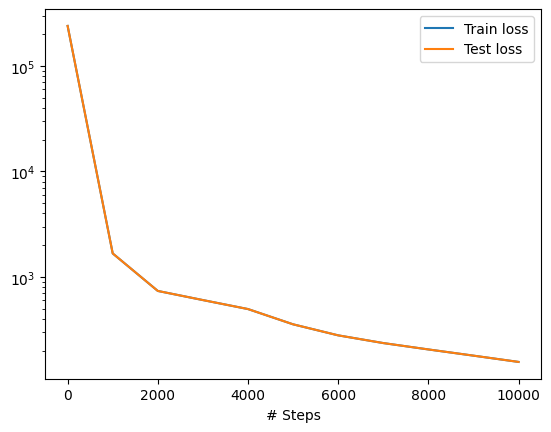

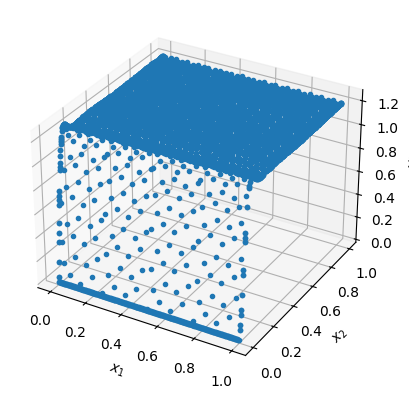

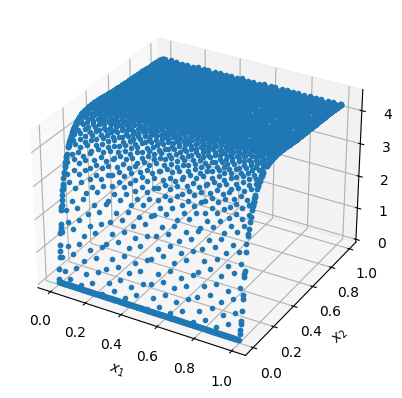

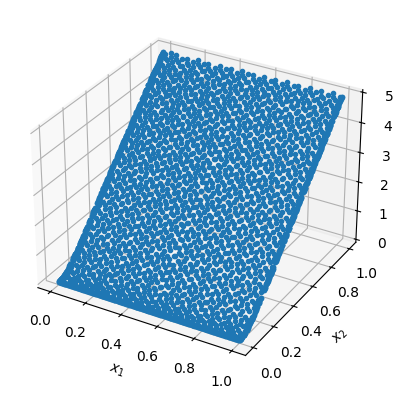

In [8]:
import deepxde as dde
import torch
import torch.nn.functional as F
import numpy as np

# ---------------------------------------------------------
# 1. SCALED PHYSICAL CONSTANTS
# ---------------------------------------------------------
ALPHA = 12.96
BETA = 16588.8
GAMMA = 345.6
DELTA = 1.2096
RHO = 4.416
P_SCALED_UPTAKE = 8.333

# ---------------------------------------------------------
# 2. THE PDE SYSTEM
# ---------------------------------------------------------
def pde_scaled(x, y):
    r_tilde = x[:, 0:1]
    t_tilde = x[:, 1:2]

    # Map the 3 outputs
    y1 = y[:, 0:1] # Interstitial [Ab^(I)]
    y2 = y[:, 1:2] # Bound [Ab^(b)]
    y3 = y[:, 2:3] # Internalized [Ab^(int)]

    # Network derivatives
    dy1_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy2_t = dde.grad.jacobian(y, x, i=1, j=1)
    dy3_t = dde.grad.jacobian(y, x, i=2, j=1)
    
    dy1_r = dde.grad.jacobian(y, x, i=0, j=0)
    d2y1_rr = dde.grad.hessian(y, x, i=0, j=0)

    # Porosity equation and its exact spatial derivatives
    phi = 0.44 * (r_tilde)**3.2 + 0.56
    phi_prime = 0.44 * 3.2 * (r_tilde)**2.2
    phi_double_prime = 0.44 * 3.2 * 2.2 * (r_tilde)**1.2

    # Prevent division by zero at the center of the spheroid (r=0)
    r_safe = torch.where(r_tilde == 0, torch.tensor(1e-7), r_tilde)
    
    # Expanded Diffusion Term
    diffusion_term = ALPHA * (
        d2y1_rr 
        + (2 / r_safe - phi_prime / phi) * dy1_r 
        - (2 / r_safe * phi_prime / phi + (phi_double_prime * phi - phi_prime**2) / phi**2) * y1
    )

    # The 3 Coupled PDEs (Residuals)
    res1 = dy1_t - diffusion_term + BETA * (y1 / phi) * (RHO - y2) - GAMMA * y2
    res2 = dy2_t - BETA * (y1 / phi) * (RHO - y2) + GAMMA * y2 + DELTA * y2
    res3 = dy3_t - DELTA * y2

    return [res1 / BETA, res2 / BETA, res3]

# ---------------------------------------------------------
# 3. LOCATION FILTERS (Where boundary conditions apply)
# ---------------------------------------------------------
def boundary_outer(x, on_boundary):
    """Filters for points exactly at the outer radius (r = 1)"""
    return on_boundary and dde.utils.isclose(x[0], 1)

def boundary_center(x, on_boundary):
    """Filters for points exactly at the center (r = 0)"""
    return on_boundary and dde.utils.isclose(x[0], 0)

# ---------------------------------------------------------
# 4. PHYSICS FACTORIES (Boundary Condition Equations)
# ---------------------------------------------------------
def get_robin_boundary_equation(P_scaled, C_bath):
    """Factory function that generates the mass-flux equation"""
    def robin_boundary_equation(x, y, X):
        r_tilde = x[:, 0:1]
        y1 = y[:, 0:1]
        
        # Compute gradient with respect to the PyTorch tensor 'x'
        dy1_r = dde.grad.jacobian(y, x, i=0, j=0)
        
        # Porosity evaluated at the boundary
        phi = 0.44 * (r_tilde)**3.2 + 0.56
        phi_prime = 0.44 * 3.2 * (r_tilde)**2.2
        
        # Mass flux residual: phi * dy1/dr - y1 * phi' - P_scaled * (phi * C_bath - y1) = 0
        residual = (phi * dy1_r) - (y1 * phi_prime) - P_scaled * (phi * C_bath - y1)
        return residual
    
    return robin_boundary_equation

# ---------------------------------------------------------
# 5. DOMAIN & INITIAL/BOUNDARY CONDITIONS SETUP
# ---------------------------------------------------------
# Normalized Domain: r in [0, 1], t in [0, 1]
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# # Initial Conditions: At t=0, all concentrations are 0 inside the spheroid
# ic_y1 = dde.icbc.IC(geomtime, lambda x: 0, lambda _, on_initial: on_initial, component=0)
# ic_y2 = dde.icbc.IC(geomtime, lambda x: 0, lambda _, on_initial: on_initial, component=1)
# ic_y3 = dde.icbc.IC(geomtime, lambda x: 0, lambda _, on_initial: on_initial, component=2)

# Boundary Conditions
# Outer edge: Robin mass-flux condition (Uptake Phase: C_bath = 1.0)
robin_uptake = get_robin_boundary_equation(P_scaled=P_SCALED_UPTAKE, C_bath=1.0)
bc_outer = dde.icbc.OperatorBC(geomtime, robin_uptake, boundary_outer)

# Center: Symmetry condition (dy1/dr = 0)
bc_center = dde.icbc.NeumannBC(geomtime, lambda x: 0, boundary_center, component=0)

# ---------------------------------------------------------
# 6. MODEL COMPILATION AND TRAINING
# ---------------------------------------------------------
data = dde.data.TimePDE(
    geomtime, 
    pde_scaled, 
    [bc_outer, bc_center], 
    num_domain=2000,   # Sample points inside the space-time domain
    num_boundary=400,  # Sample points on the space boundaries
    num_initial=400    # Sample points at t=0
)

# Neural Network Architecture: 3 hidden layers of width 64
layer_size = [2] + [64] * 3 + [3]
net = dde.nn.FNN(layer_size, "tanh", "Glorot uniform")
print(f'neural net architecture {net}')
# net.apply_output_transform(lambda x, y: x[:, 1:2] * y) # multiply the output of nn with t to embed the initial condition.
net.apply_output_transform(lambda x, y: x[:, 1:2] * F.softplus(y)) # force ic and positive concentration.

model = dde.Model(data, net)

# Compile using Adam (Weights added to prioritize BCs/ICs to help convergence)
model.compile("adam", lr=1e-3, loss_weights=[1, 1, 1, 100, 100])

print("Starting Adam training phase...")
losshistory, train_state = model.train(iterations=10000)

# Plot the results
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

# print('Starting L-BFGS training...')
# model.compile("L-BFGS")
# losshistory, train_state = model.train()
# # Plot the results
# dde.saveplot(losshistory, train_state, issave=False, isplot=True)


Starting Adam training phase...
Training model...

Step      Train loss                                            Test loss                                             Test metric
2000      [9.30e-04, 8.68e-04, 5.93e-03, 1.71e+03, 1.92e-11]    [9.30e-04, 8.68e-04, 5.93e-03, 1.71e+03, 1.92e-11]    []  
3000      [4.52e-04, 1.82e-04, 3.50e-03, 1.71e+03, 2.25e-11]    [4.52e-04, 1.82e-04, 3.50e-03, 1.71e+03, 2.25e-11]    []  
4000      [3.12e-04, 2.94e-05, 1.12e-03, 1.71e+03, 1.90e-11]    [3.12e-04, 2.94e-05, 1.12e-03, 1.71e+03, 1.90e-11]    []  
5000      [2.76e-04, 1.22e-05, 2.58e-04, 1.71e+03, 1.64e-11]    [2.76e-04, 1.22e-05, 2.58e-04, 1.71e+03, 1.64e-11]    []  
6000      [2.50e-04, 6.11e-06, 7.55e-05, 1.71e+03, 1.47e-11]    [2.50e-04, 6.11e-06, 7.55e-05, 1.71e+03, 1.47e-11]    []  
7000      [2.26e-04, 2.79e-06, 2.82e-05, 1.71e+03, 1.32e-11]    [2.26e-04, 2.79e-06, 2.82e-05, 1.71e+03, 1.32e-11]    []  
8000      [2.00e-04, 1.25e-06, 1.19e-05, 1.71e+03, 1.15e-11]    [2.00e-04, 1.25e-

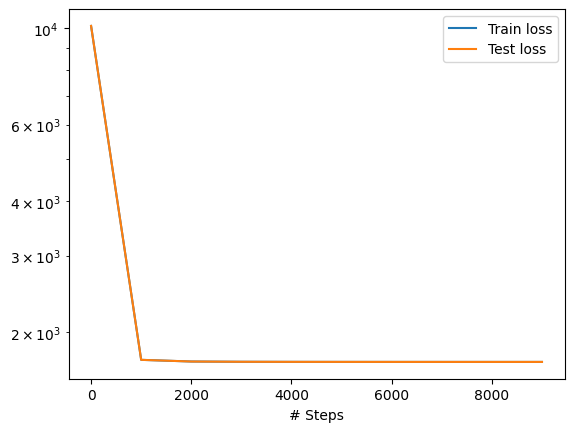

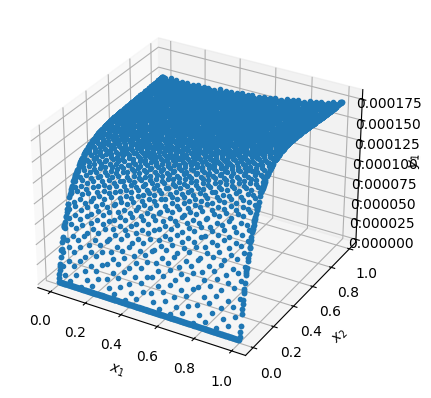

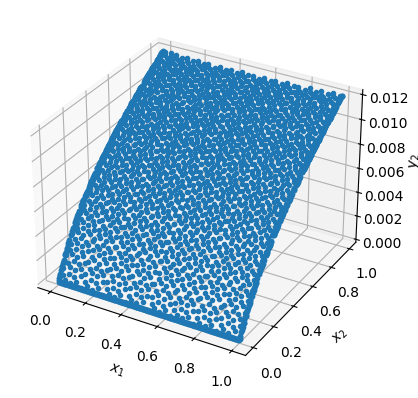

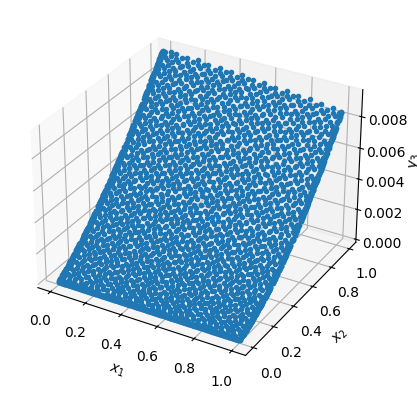

In [2]:
print("Starting Adam training phase...")
losshistory, train_state = model.train(iterations=7000)

# Plot the results
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

In [ ]:
import deepxde as dde
import torch
import torch.nn.functional as F

# ---------------------------------------------------------
# 1. SCALED PHYSICAL CONSTANTS
# ---------------------------------------------------------
ALPHA = 12.96
BETA = 16588.8
GAMMA = 345.6
DELTA = 1.2096
RHO = 4.416
P_SCALED_UPTAKE = 8.333

# ---------------------------------------------------------
# 2. THE PDE SYSTEM
# ---------------------------------------------------------
def pde_scaled(x, y):
    r_tilde = x[:, 0:1]
    t_tilde = x[:, 1:2]

    # Map the 3 outputs
    y1 = y[:, 0:1] # Interstitial [Ab^(I)]
    y2 = y[:, 1:2] # Bound [Ab^(b)]
    y3 = y[:, 2:3] # Internalized [Ab^(int)]

    # Network derivatives
    dy1_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy2_t = dde.grad.jacobian(y, x, i=1, j=1)
    dy3_t = dde.grad.jacobian(y, x, i=2, j=1)
    
    dy1_r = dde.grad.jacobian(y, x, i=0, j=0)
    d2y1_rr = dde.grad.hessian(y, x, i=0, j=0)

    # Porosity equation and its exact spatial derivatives
    phi = 4.4 * (r_tilde)**3.2 + 0.56
    phi_prime = 4.4 * 3.2 * (r_tilde)**2.2
    phi_double_prime = 4.4 * 3.2 * 2.2 * (r_tilde)**1.2

    # Prevent division by zero at the center of the spheroid (r=0)
    r_safe = torch.where(r_tilde == 0, torch.tensor(1e-7), r_tilde)
    
    # Expanded Diffusion Term
    diffusion_term = ALPHA * (
        d2y1_rr 
        + (2 / r_safe - phi_prime / phi) * dy1_r 
        - (2 / r_safe * phi_prime / phi + (phi_double_prime * phi - phi_prime**2) / phi**2) * y1
    )

    # The 3 Coupled PDEs (Residuals)
    res1 = dy1_t - diffusion_term + BETA * (y1 / phi) * (RHO - y2) - GAMMA * y2
    res2 = dy2_t - BETA * (y1 / phi) * (RHO - y2) + GAMMA * y2 + DELTA * y2
    res3 = dy3_t - DELTA * y2

    # CRITICAL FIX: Normalize stiff equations to prevent exploding errors
    return [res1 / BETA, res2 / BETA, res3]

# ---------------------------------------------------------
# 3. LOCATION FILTER
# ---------------------------------------------------------
def boundary_outer(x, on_boundary):
    """Filters for points exactly at the outer radius (r = 1)"""
    return on_boundary and dde.utils.isclose(x[0], 1)

# ---------------------------------------------------------
# 4. PHYSICS FACTORY (Robin Boundary Equation)
# ---------------------------------------------------------
def get_robin_boundary_equation(P_scaled, C_bath):
    """Factory function that generates the mass-flux equation"""
    def robin_boundary_equation(x, y, X):
        r_tilde = x[:, 0:1]
        y1 = y[:, 0:1]
        dy1_r = dde.grad.jacobian(y, x, i=0, j=0)
        
        # Porosity evaluated at the boundary
        phi = 4.4 * (r_tilde)**3.2 + 0.56
        phi_prime = 4.4 * 3.2 * (r_tilde)**2.2
        
        # Mass flux residual: phi * dy1/dr - y1 * phi' - P_scaled * (phi * C_bath - y1) = 0
        residual = (phi * dy1_r) - (y1 * phi_prime) - P_scaled * (phi * C_bath - y1)
        return residual
    
    return robin_boundary_equation

# ---------------------------------------------------------
# 5. HARD CONSTRAINTS (Input & Output Transforms)
# ---------------------------------------------------------
def symmetric_feature_transform(x):
    """Forces Neumann Symmetry at the center by replacing r with r^2"""
    r_in = x[:, 0:1]
    t_in = x[:, 1:2]
    return torch.cat([r_in**2, t_in], dim=1)

def physics_bounds_transform(x, y):
    """Forces Initial Conditions and Upper/Lower Concentration Bounds"""
    y1_raw = y[:, 0:1]
    y2_raw = y[:, 1:2]
    y3_raw = y[:, 2:3]
    
    # Apply Physical Constraints (Sigmoid for limits, Softplus for positivity)
    y1_bound = torch.sigmoid(y1_raw) 
    y2_bound = RHO * torch.sigmoid(y2_raw) 
    y3_bound = F.softplus(y3_raw) 
    
    y_constrained = torch.cat([y1_bound, y2_bound, y3_bound], dim=1)
    
    # Multiply by time to enforce ICs: when t=0, concentrations=0
    return x[:, 1:2] * y_constrained

# ---------------------------------------------------------
# 6. DOMAIN & MODEL SETUP
# ---------------------------------------------------------
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

# Outer edge Robin condition
robin_uptake = get_robin_boundary_equation(P_scaled=P_SCALED_UPTAKE, C_bath=1.0)
bc_outer = dde.icbc.OperatorBC(geomtime, robin_uptake, boundary_outer)

data = dde.data.TimePDE(
    geomtime, 
    pde_scaled, 
    [bc_outer], # ICs and Center Neumann are handled by hard transforms!
    num_domain=2000,   
    num_boundary=400,  
    num_initial=400    
)

layer_size = [2] + [64] * 3 + [3]
net = dde.nn.FNN(layer_size, "tanh", "Glorot uniform")

# Apply the strict mathematical constraints to the network architecture
net.apply_feature_transform(symmetric_feature_transform)
net.apply_output_transform(physics_bounds_transform)

model = dde.Model(data, net)

# ---------------------------------------------------------
# 7. TRAINING PIPELINE
# ---------------------------------------------------------
# Loss weights match the 3 PDEs and 1 Boundary Condition
model.compile("adam", lr=1e-3, loss_weights=[1, 1, 1, 10])

print("Starting Adam training phase...")
model.train(iterations=10000)

print("Starting L-BFGS polishing phase...")
# L-BFGS takes over to push the final errors as close to 0 as mathematically possible
model.compile("L-BFGS")
losshistory, train_state = model.train()

# Plot the training progression
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

In [97]:
### utilities.
def plot_dataset(dataset: dde.data.TimePDE, point_size=0.1):
    x_train = dataset.train_x_all
    dist = dataset.train_distribution
    plt.scatter(x_train[:, 0], x_train[:, 1], s=point_size)
    plt.title(f'points: {len(x_train)}, dist: {dist}')
    plt.xlabel('r')
    plt.ylabel('t')
    plt.show()

In [ ]:
########################### reaction-diffucion example ###########################
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from deepxde.backend import pytorch
dde.backend.set_default_backend("pytorch")

### 1. Define the computational domain.
# Define domain objects.
geom_radius = dde.geometry.Interval(0, 1)
geom_time = dde.geometry.TimeDomain(0, 1)

# fuse the space-time domain.
geom_space_time = dde.geometry.GeometryXTime(geom_radius, geom_time)

### 2. Mathematical processing.


# Define filter funcions to specify where the bc will be applied.
def left_wall_filter(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 0.0)

# Define icbc.
bc_left = dde.icbc.DirichletBC(
    geom=geom_space_time,
    func=lambda x: 100.0,
    on_boundary=left_wall_filter,
    component=0
)

# Create the dataset object.
dataset = dde.data.TimePDE(
    geometryxtime=geom_space_time,
    pde=None,
    ic_bcs=[bc_left],
    num_domain=4000,
    num_boundary=400,
    num_initial=400,
    train_distribution='LHS'
)
# plot_dataset(dataset, point_size=0.25)
dataset.train_x_bc


def center_bc():
    return 1.0
def left_wall_folter(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[:, 0:1], 0.0)

dde.icbc.DirichletBC(
    geom=geom_space_time,
    func=center_bc,
    on_boundary=None,
    component=None
)

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [ ]:
# Poisson equation in 1D with Dirichlet boundary conditions.

geom = dde.geometry.Interval(-1, 1)

def pde(x, y):
    dy_xx = dde.grad.hessian(y, x)
    return -dy_xx - np.pi ** 2 * torch.sin(np.pi * x)


def boundary(x, on_boundary):
    return on_boundary

def func_bc(x):
    return 0

def solution(x):
    return np.sin(np.pi * x)

bc = dde.icbc.DirichletBC(
    geom=geom,
    func=func_bc,
    on_boundary=boundary
)

data = dde.data.PDE(geom, pde, bc, num_domain=16, num_boundary=2, solution=solution , num_test=100)

layer_size = [1] + [50] * 3 + [1]
net = dde.nn.FNN(layer_size, "tanh", "Glorot uniform")

model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

# Create callbacks.
checkpointer = dde.callbacks.ModelCheckpoint('model/model.ckpt', verbose=1, save_better_only=True)
movie = dde.callbacks.MovieDumper("model/movie", [-1], [1], period=100, save_spectrum=True, y_reference=solution)


losshistory, train_state = model.train(iterations=10000, callbacks=[checkpointer, movie])
dde.saveplot(losshistory, train_state, issave=True, isplot=True)


# restore the best state and plot the residual.
model.restore(f'model/model.ckpt-{train_state.best_step}.pt', verbose=1)

x = geom.uniform_points(1000, True)
y = model.predict(x, operator=pde)

plt.figure()
plt.plot(x, y)
plt.ylabel('pde residual')
plt.show()

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Compiling model...
'compile' took 0.000134 s

Training model...

Step      Train loss                                                      Test loss                                                       Test metric
0         [9.87e-02, 2.24e-02, 1.65e-02, 3.68e+00, 2.08e-01, 6.72e-01]    [9.94e-02, 2.23e-02, 1.65e-02, 3.68e+00, 2.08e-01, 6.72e-01]    []  
1000      [2.06e-02, 1.19e-02, 1.20e-02, 1.56e-01, 3.62e-02, 1.15e-03]    [1.42e-02, 9.33e-03, 8.67e-03, 1.56e-01, 3.62e-02, 1.15e-03]    []  
2000      [1.12e-02, 4.00e-03, 3.78e-03, 2.84e-02, 1.17e-02, 4.59e-04]    [8.83e-03, 2.68e-03, 2.62e-03, 2.84e-02, 1.17e-02, 4.59e-04]    []  

Best model at step 2000:
  train loss: 5.96e-02
  test loss: 5.47e-02
  test metric: []

'train' took 90.704276 s

Saving loss history to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/loss.dat ...
Saving training data to /Users/giorgosvlachonikoleas/Developer/Spheroid_PINN_Project/train.dat ...
Saving test data to /Users/giorgosvlachoniko

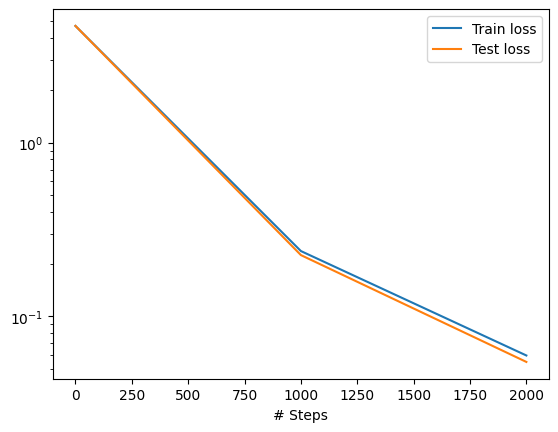

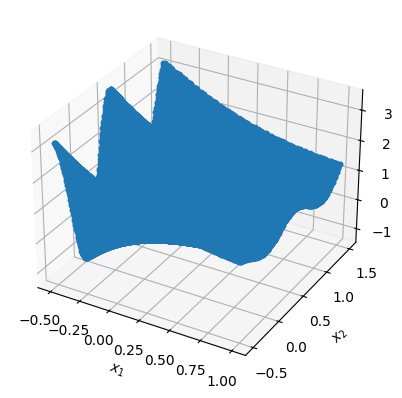

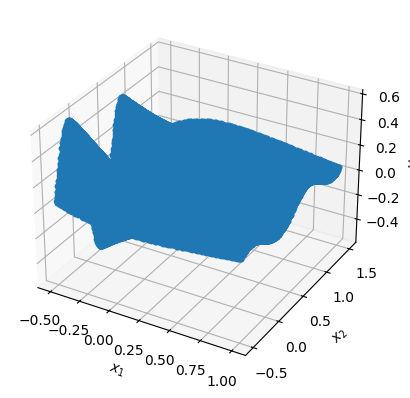

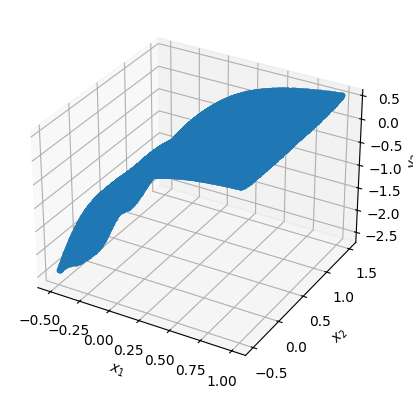

In [2]:
# Kovasznay flow.

# Import nessesary modules.
import deepxde as dde
import numpy as np

# Define the parameters of the problem.
Re = 20
nu = 1 / Re
l = 1 / (2 * nu) - np.sqrt(1 / (4 * nu ** 2) + 4 * np.pi ** 2)

# Define the residual of the pde.
def pde(x, u):
    '''
    first derivative args:
        i = The index of the Neural Network Output
        j = The index of the Computational Domain Input
    second derivative args:
        component = The index of the Neural Network Output
        i = The index of the First Input Variable
        j = The index of the Second Input Variable
    '''
    u_vel, v_vel, p = u[:, 0:1], u[:, 1:2], u[:, 2:]
    u_vel_x = dde.grad.jacobian(u, x, i=0, j=0)
    u_vel_y = dde.grad.jacobian(u, x, i=0, j=1)
    u_vel_xx = dde.grad.hessian(u, x, component=0, i=0, j=0)
    u_vel_yy = dde.grad.hessian(u, x, component=0, i=1, j=1)

    v_vel_x = dde.grad.jacobian(u, x, i=1, j=0)
    v_vel_y = dde.grad.jacobian(u, x, i=1, j=1)
    v_vel_xx = dde.grad.hessian(u, x, component=1, i=0, j=0)
    v_vel_yy = dde.grad.hessian(u, x, component=1, i=1, j=1)

    p_x = dde.grad.jacobian(u, x, i=2, j=0)
    p_y = dde.grad.jacobian(u, x, i=2, j=1)

    momentum_x = (
        u_vel * u_vel_x + v_vel * u_vel_y + p_x - 1 / Re * (u_vel_xx + u_vel_yy)
    )
    momentum_y = (
        u_vel * v_vel_x + v_vel * v_vel_y + p_y - 1 / Re * (v_vel_xx + v_vel_yy)
    )
    continuity = u_vel_x + v_vel_y

    return [momentum_x, momentum_y, continuity]

# Define the exact solutions.
def u_func(x):
    return 1 - np.exp(l * x[:, 0:1]) * np.cos(2 * np.pi * x[:, 1:2])

def v_func(x):
    return l / (2 * np.pi) * np.exp(l * x[:, 0:1]) * np.sin(2 * np.pi * x[:, 1:2])

def p_func(x):
    return 1 / 2 * (1 - np.exp(2 * l * x[:, 0:1]))

# Define boundary conditions.
spatial_domain = dde.geometry.Rectangle(xmin=[-0.5, -0.5], xmax=[1, 1.5])

def boundary_outflow(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1)

bc_u = dde.icbc.DirichletBC(geom=spatial_domain, func=u_func, on_boundary=lambda _, on_boundary: on_boundary, component=0)
bc_v = dde.icbc.DirichletBC(geom=spatial_domain, func=v_func, on_boundary=lambda _, on_boundary: on_boundary, component=1)
bc_p = dde.icbc.DirichletBC(geom=spatial_domain, func=p_func, on_boundary=boundary_outflow, component=2)

# Define the pde problem
data = dde.data.PDE(
    geometry=spatial_domain,
    pde=pde,
    bcs=[bc_u, bc_v, bc_p],
    num_domain=2601,
    num_boundary=400,
    num_test=100000
)

# Create the network object.
net = dde.nn.FNN([2] + 4 * [50] + [3], "tanh", "Glorot normal")

# Build the model.
model = dde.Model(data=data, net=net)
model.compile(optimizer='adam', lr=0.001)
losshistory, train_state = model.train(iterations=2000)
# model.compile(optimizer='L-BFGS')
# losshistory, train_state = model.train()   

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

In [61]:
import matplotlib.pyplot as plt
import deepxde as dde
import numpy as np

dde.backend.set_default_backend('pytorch')

spacedomain = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 10)
geomtime = dde.geometry.GeometryXTime(spacedomain, timedomain)

def dummy_pde(x, y):
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    return dy_t - 0.1 * y

def left_boundary_filter(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 0.0)

def right_boundary_filter(x, on_boundary):
    return on_boundary and dde.utils.isclose(x[0], 1.0)

bc_left = dde.icbc.DirichletBC(geomtime, lambda x: 100.0, left_boundary_filter, component=0)
bc_right = dde.icbc.DirichletBC(geomtime, lambda x: 0.0, right_boundary_filter, component=0)

data = dde.data.TimePDE(geometryxtime=geomtime, pde=dummy_pde, ic_bcs=[bc_left, bc_right], num_domain=100, num_boundary=20, num_initial=30)

Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [63]:
left_idx = data.num_bcs[0]
right_idx = data.num_bcs[1]
all_bc = data.train_x_bc
print(f'left boundary points:\n{all_bc[:left_idx]}')
print(f'right boundary points:\n{all_bc[left_idx:left_idx+right_idx]}')
data.train_x_all[0:30]

initial_idx = data.num_initial
data.train_x_all[:initial_idx+1]


left boundary points:
[[0.     0.3125]
 [0.     7.8125]
 [0.     7.5   ]
 [0.     2.8125]
 [0.     8.125 ]
 [0.     6.25  ]
 [0.     2.5   ]
 [0.     1.25  ]
 [0.     5.3125]]
right boundary points:
[[1.     8.75  ]
 [1.     6.875 ]
 [1.     4.375 ]
 [1.     3.75  ]
 [1.     9.375 ]
 [1.     1.875 ]
 [1.     0.625 ]
 [1.     5.    ]
 [1.     1.5625]
 [1.     5.625 ]
 [1.     3.125 ]]


array([[0.5    , 0.     ],
       [0.25   , 0.     ],
       [0.75   , 0.     ],
       [0.125  , 0.     ],
       [0.625  , 0.     ],
       [0.375  , 0.     ],
       [0.875  , 0.     ],
       [0.0625 , 0.     ],
       [0.5625 , 0.     ],
       [0.3125 , 0.     ],
       [0.8125 , 0.     ],
       [0.1875 , 0.     ],
       [0.6875 , 0.     ],
       [0.4375 , 0.     ],
       [0.9375 , 0.     ],
       [0.03125, 0.     ],
       [0.53125, 0.     ],
       [0.28125, 0.     ],
       [0.78125, 0.     ],
       [0.15625, 0.     ],
       [0.65625, 0.     ],
       [0.40625, 0.     ],
       [0.90625, 0.     ],
       [0.09375, 0.     ],
       [0.59375, 0.     ],
       [0.34375, 0.     ],
       [0.84375, 0.     ],
       [0.21875, 0.     ],
       [0.71875, 0.     ],
       [0.46875, 0.     ],
       [1.     , 8.75   ]], dtype=float32)

In [71]:
data.train_x_all[dde.utils.isclose(data.train_x_all[:, 0], 1.0)]

array([[1.    , 8.75  ],
       [1.    , 6.875 ],
       [1.    , 4.375 ],
       [1.    , 3.75  ],
       [1.    , 9.375 ],
       [1.    , 1.875 ],
       [1.    , 0.625 ],
       [1.    , 5.    ],
       [1.    , 1.5625],
       [1.    , 5.625 ],
       [1.    , 3.125 ]], dtype=float32)

In [4]:
# make a test set according to the geometry of the problem.

batch_size = 100000
X = spatial_domain.random_points(batch_size)
assert X.shape == (batch_size, 2), "wrong shape"
output = model.predict(X)
assert output.shape == (batch_size, 3)
u_pred = output[:, 0:1]
v_pred = output[:, 1:2]
p_pred = output[:, 2:3]

u_exact = u_func(X).reshape(-1)
v_exact = v_func(X).reshape(-1)
p_exact = p_func(X).reshape(-1)

f = model.predict(X, operator=pde)
res = np.mean(np.absolute(f))

l2_u = dde.metrics.l2_relative_error(u_exact, u_pred)
l2_v = dde.metrics.l2_relative_error(v_exact, v_pred)
l2_p = dde.metrics.l2_relative_error(p_exact, p_pred)

print(f'Mean residual: {res}')
print("L2 relative error in u:", l2_u)
print("L2 relative error in v:", l2_v)
print("L2 relative error in p:", l2_p)

: 

: 

In [98]:
def count_up_to(n):
    # Yield numbers here
    for number in range(1, n+1):
        yield number

a = count_up_to(9)
a.__hash__

<method-wrapper '__hash__' of generator object at 0x115707350>

In [39]:
from dataclasses import dataclass, field
import numpy as np
from enum import Enum, auto

@dataclass(frozen=True)
class PhaseType(Enum):
    uptake = auto()
    fishing = auto()
    clearance = auto()

@dataclass
class PhaseSpecification:
    phase_type: PhaseType
    tau: float
    outer_boundary_concentration: float
    time_window: tuple[float, float] = (0, 1)

@dataclass
class Antibody:
    D: float 
    P: float
    Koff: float
    Kd: float 
    Kint: float 
    Rt: float 
    C_ext: float 
    phi: lambda r: 0.44 * r**3.2 + 0.56

@dataclass
class CharacteristicUnits:
    C0: float
    R: float   

@dataclass
class DimLessModel:
    antibody :Antibody
    units :CharacteristicUnits
    specification :PhaseSpecification
    
    D_star: float = field(init=False)
    Kon_star: float = field(init=False)
    Koff_star: float = field(init=False)
    Kint_star: float = field(init=False)
    Rt_star: float = field(init=False)

    def __post_init__(self):
        ab, un, sp = self.antibody, self.units, self.specification

        Kon = ab.Koff / ab.Kd

        self.D_star = sp.tau / un.R**2 * ab.D
        self.Kon_star = un.C0 * sp.tau * Kon
        self.Koff_star = sp.tau * ab.Koff
        self.Kint_star = sp.tau * ab.Kint
        self.Rt_star = ab.Rt / un.C0

In [45]:
transtuzumab = Antibody(D=8.38, P=0, Koff=4e-3, Kd=6.76, Kint=1.4e-5, Rt=1060, C_ext=60, phi=lambda r: 0.44 * r**3.2 + 0.56)
units = CharacteristicUnits(C0=60, R=100)
uptake_spec = PhaseSpecification(PhaseType.uptake.name, tau=24, outer_boundary_concentration=60)
uptake_model = DimLessModel(transtuzumab, units, uptake_spec)
uptake_model.antibody

Antibody(D=8.38, P=0, Koff=0.004, Kd=6.76, Kint=1.4e-05, Rt=1060, C_ext=60, phi=<function <lambda> at 0x10f5b8ee0>)

In [2]:
transtuzumab = Antibody(D=8.38, P=0, Koff=4e-3, Kd=6.76, Kint=1.4e-5, Rt=1060, C_ext=60)

char_units_up = CharacteristicUnits(C0=60, R=200, tau=24*3600)
char_units_fi = CharacteristicUnits(C0=60, R=200, tau=30)
char_units_cl = CharacteristicUnits(C0=60, R=200, tau=24*3600)

uptake_dimless_model = DimLessModel(transtuzumab, char_units_up)
fishing_dimless_model = DimLessModel(transtuzumab, char_units_fi)
clearance_dimless_model = DimLessModel(transtuzumab, char_units_cl)

print('Transtuzimav')
print(transtuzumab)

print('\nCharacteristic Units for Uptake Phase')
print(char_units_up)
print(uptake_dimless_model.get_dimless_params())

print('\nCharacteristic Units for Fishing Phase')
print(char_units_fi)
print(fishing_dimless_model.get_dimless_params())

print('\nCharacteristic Units for Clearance Phase')
print(char_units_cl)
print(clearance_dimless_model.get_dimless_params())


Transtuzimav
Antibody(D=8.38, P=0, Koff=0.004, Kd=6.76, Kint=1.4e-05, Rt=1060, C_ext=60)

Characteristic Units for Uptake Phase
CharacteristicUnits(C0=60, R=200, tau=86400)
DimLessParams(D_star=18.100800000000003, Kon_star=3067.4556213017754, Koff_star=345.6, Kint_star=1.2096, Rt_star=17.666666666666668)

Characteristic Units for Fishing Phase
CharacteristicUnits(C0=60, R=200, tau=30)
DimLessParams(D_star=0.006285000000000001, Kon_star=1.0650887573964498, Koff_star=0.12, Kint_star=0.00042, Rt_star=17.666666666666668)

Characteristic Units for Clearance Phase
CharacteristicUnits(C0=60, R=200, tau=86400)
DimLessParams(D_star=18.100800000000003, Kon_star=3067.4556213017754, Koff_star=345.6, Kint_star=1.2096, Rt_star=17.666666666666668)


In [ ]:
from torch.export import Dim


DimLessParams(alpha=0.000324, beta=8.333333333333334, gamma=16588.8, delta=1.2096

AttributeError: 'Antibody' object has no attribute '__name__'

In [180]:
trast_uptake.params


AntibodyParams(D=8.38, P=8.333, Koff=0.004, Kd=6.76, R=200, tau=86400, R_t=1060, C_sol=60)

In [230]:
from abc import ABC, abstractmethod

class Animal(ABC):

    @abstractmethod
    def sound(self):
        pass

    @abstractmethod
    def color(self):
        pass

In [233]:
class Dog(Animal):
    def sound(self)->str:
         return "Woof!"
    def color(self)->str:
        return "Brown"
    

In [236]:
poodle = Dog()
poodle.color()


'Brown'